# Section 2: Malthusian Growth Model

## Background
The **Malthusian growth model** is a mathematical model of population growth that essentially describes **exponential population growth**. The model is named after **Thomas Robert Malthus** (1766 - 1834), an English economist who wrote *An Essay on the Principle of Population* (1798).



### Key Assumptions of Thomas Malthus
* **Exponential Growth:** Population grows exponentially when resources are abundant.
* **Linear Resource Growth:** Malthus assumed agricultural production increases only linearly (arithmetically).
* **Limiting Factors:** Growth is limited by resources and can be reduced by famine, disease, or war.



> **Malthusian Catastrophe:** A situation where the population exceeds the agricultural production of its environment, resulting in severe consequences like poverty, famine, disease, and war.

### Malthus, Darwin, and Natural Selection
Malthus's work was instrumental to **Charles Darwin**. Darwin realized that as populations breed beyond their means, competition for resources ensures that advantageous traits become more prevalent. This insight led to the development of the theory of **natural selection**.

### Neo-Malthusianism
In the 20th century, Neo-Malthusians revived these concerns, focusing on environmental limits, overpopulation, and resource depletion. A famous example is Paul Ehrlich's *The Population Bomb* (1968).

---

## The Mathematics of Malthusian Growth

The change in population $dP/dt$ is proportional to the current population size $P$ at time $t$. The parameter $r$ is the **intrinsic rate of increase** (birth rate minus death rate).

$$\frac{dP}{dt} = rP$$

### Deriving the Explicit Solution
1.  **Separate Variables:** $\frac{dP}{P} = r dt$.
2.  **Integrate:** $\int \frac{dP}{P} = \int r dt \implies \ln|P| = rt + C$.
3.  **Exponentiate:** $P = e^{rt+C} = e^C e^{rt}$.
4.  **Final Form:** Letting $e^C$ be the initial population $P_0$:

$$P(t) = P_0 e^{rt}$$

## Numerical vs Explicit Solutions

| Feature | Explicit (Analytical) Solution | Numerical Solution (Euler's Method) |
| :--- | :--- | :--- |
| **Definition** | A mathematically **exact** formula. | **Iterative approximation** using computational steps. |
| **Pros** | Precise value for any $t$; deep mathematical insight. | Solves complex, non-linear problems where parameters change. |
| **Cons** | Often impossible for complex problems. | Approximate; prone to discretization errors. |



### Euler's Method Algorithm
1.  **Discretization:** $t_{i+1} = t_i + \Delta t$.
2.  **Iteration:** $P(t_{i+1}) = P(t_i) + r P(t_i) \Delta t$.

## Exercises

### Task 2.1: Population at Discrete Times
Calculate the population of Senegal (starting in 1950) at specific years using the explicit formula.
* $P_0 = 2.5$ million
* $r = 2.7\%$ (0.027)

In [1]:
import numpy as np

P0 = 2.5   # Initial population (millions)
r = 0.027  # Growth rate 2.7%

t_task1 = np.array([1, 5, 7.5, 25.78])

print("Years of interest:")
print(t_task1)
print("Calculated population size (Millions):")
print(P0 * np.exp(r * t_task1))

Years of interest:
[ 1.    5.    7.5  25.78]
Calculated population size (Millions):
[2.56841951 2.86134196 3.06115021 5.01458533]


### Task 2.2: Continuous Modeling (Explicit)
Calculate and plot the population for the next 70 years using a 1-year time step.

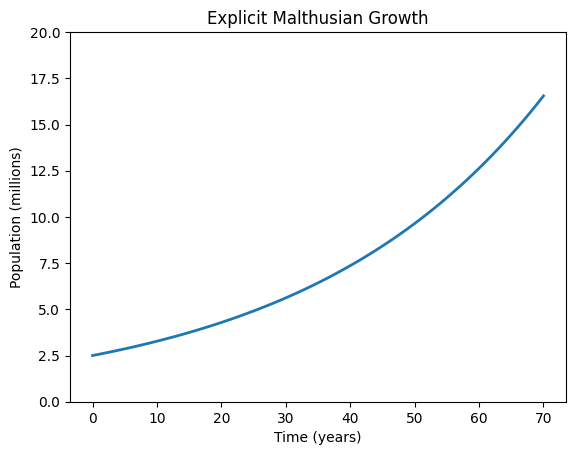

In [2]:
import matplotlib.pyplot as plt

P0 = 2.50
r = 0.027
t_start, t_end, t_diff = 0, 70, 1

t_expl = np.arange(t_start, t_end + t_diff, t_diff)
P_expl = P0 * np.exp(r * t_expl)

plt.plot(t_expl, P_expl, linewidth=2)
plt.title("Explicit Malthusian Growth")
plt.xlabel("Time (years)")
plt.ylabel("Population (millions)")
plt.ylim(0, 20)
plt.show()

### Task 2.3: Numerical Approach (Euler's Method)
Perform the same calculation using the numerical approach.

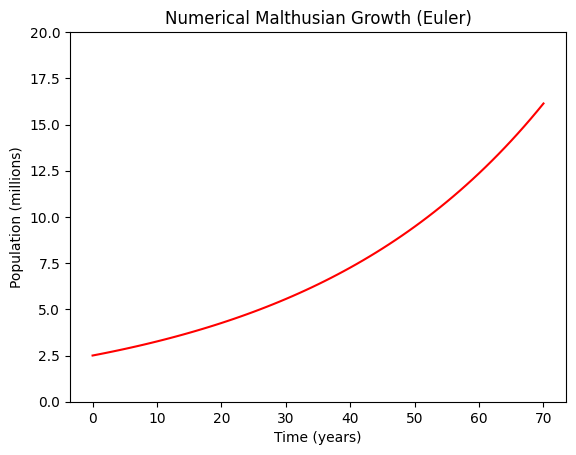

In [3]:
P0, r = 2.50, 0.027
t_start, t_end, t_diff = 0, 70, 1

t_num = [t_start]
P_num = [P0]

for i in range(int(t_end/t_diff)):
    P_new = P_num[i] + r * P_num[i] * t_diff
    t_new = t_num[i] + t_diff
    P_num.append(P_new)
    t_num.append(t_new)

plt.plot(t_num, P_num, color="red")
plt.title("Numerical Malthusian Growth (Euler)")
plt.xlabel("Time (years)")
plt.ylabel("Population (millions)")
plt.ylim(0, 20)
plt.show()

### Task 2.4: Impact of Time Step on Error
Compare the explicit and numerical solutions. A large step size (1 year) leads to substantial error. Smaller steps (1 month or 1 day) reduce error significantly.

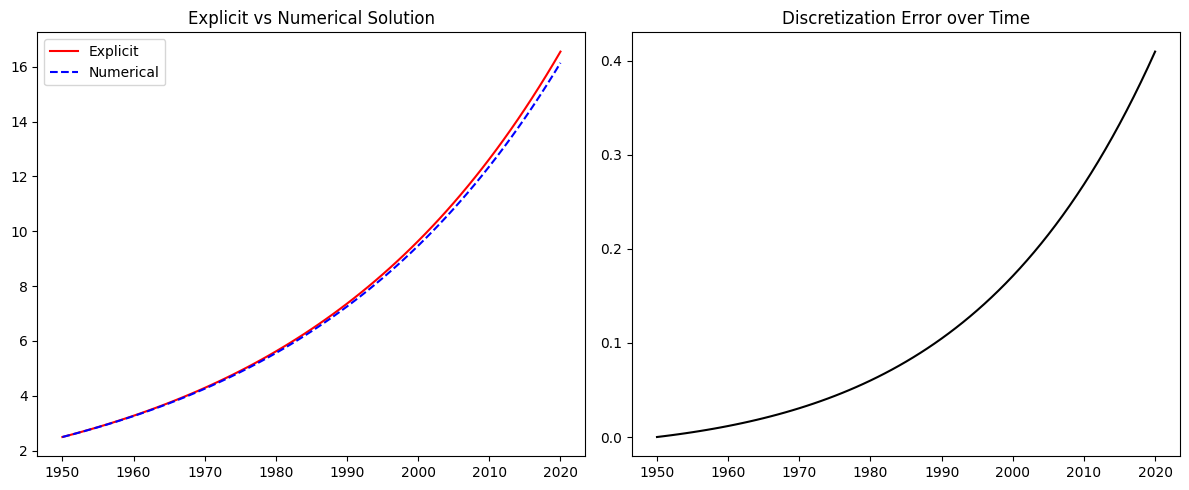

In [4]:
# Comparing Explicit vs Numerical with 1-year step
t_num_arr = np.array(t_num)
P_num_arr = np.array(P_num)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(t_expl + 1950, P_expl, color="red", label="Explicit")
ax1.plot(t_num_arr + 1950, P_num_arr, color="blue", linestyle="--", label="Numerical")
ax1.set_title("Explicit vs Numerical Solution")
ax1.legend()

ax2.plot(t_expl + 1950, P_expl - P_num_arr, color="black")
ax2.set_title("Discretization Error over Time")
plt.tight_layout()
plt.show()

### Task 2.5 &
Simple models can often capture reality well for specific periods. However, over long durations (e.g., USA), growth rates often slow down as resources become limited, causing the model to diverge from reality.

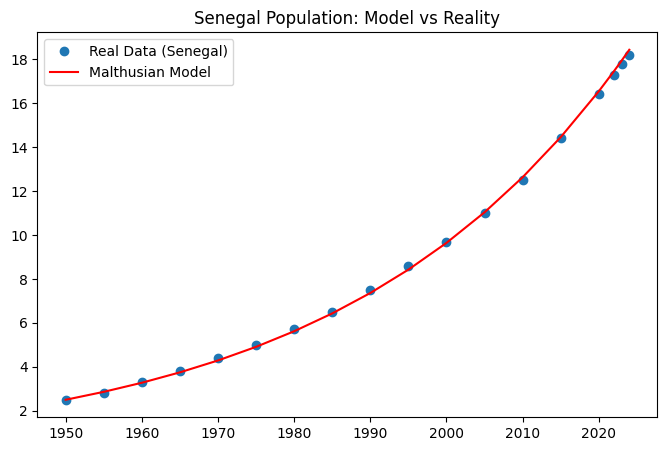

In [6]:
# Real data for Senegal
t_sen = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 72, 73, 74])
P_sen = np.array([2.5, 2.8, 3.3, 3.8, 4.4, 5.0, 5.7, 6.5, 7.5, 8.6, 9.7, 11.0, 12.5, 14.4, 16.4, 17.3, 17.8, 18.2])

P_expl_sen = P_sen[0] * np.exp(0.027 * t_sen)

plt.figure(figsize=(8, 5))
plt.plot(t_sen + 1950, P_sen, 'o', label="Real Data (Senegal)")
plt.plot(t_sen + 1950, P_expl_sen, color="red", label="Malthusian Model")
plt.title("Senegal Population: Model vs Reality")
plt.legend()
plt.show()

### 2.6: Real World Data (Senegal & USA)

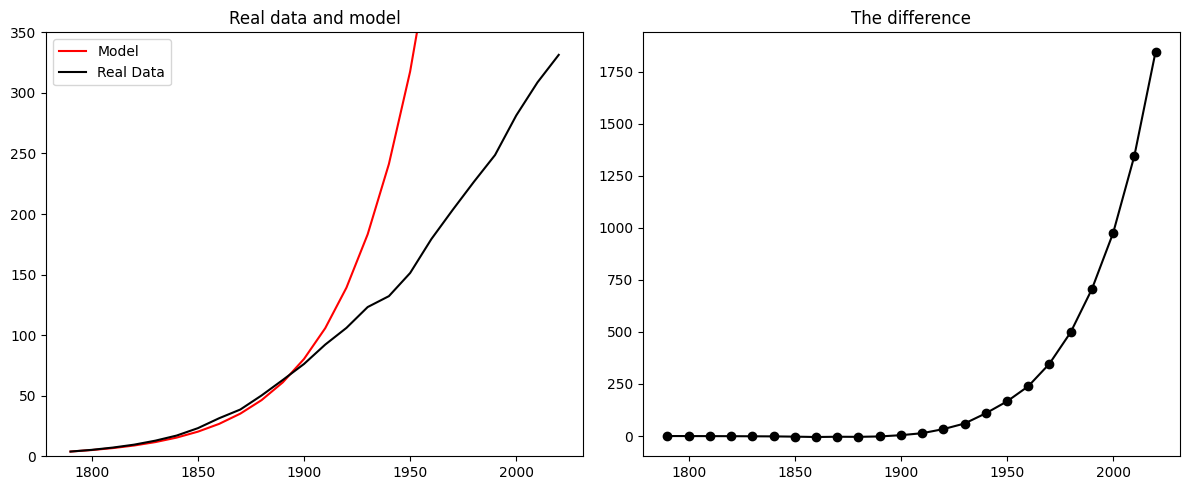

In [7]:
# Parameters
r = 0.0275
start_year = 1790

# Time axis: equivalent to 0:10:230
t_usa = np.arange(0, 240, 10) 

# US population data (Millions)
P_usa = np.array([ 3.9, 5.3, 7.2, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 63.0, 76.2, 92.2, 106.0, 123.2, 132.2, 151.3, 179.3, 203.3, 226.5, 248.7, 281.4, 308.7, 331.4])

# EXPLICIT SOLUTION
# P(t) = P0 * e^(rt)
P_expl = P_usa[0] * np.exp(r * t_usa)

# PLOTTING
years = t_usa + start_year
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Tile 1: Real data and model
ax1.plot(years, P_expl, color="red", label="Model")
ax1.plot(years, P_usa, color="black", label="Real Data")
ax1.set_title("Real data and model")
ax1.set_ylim(0, 350)
ax1.legend()

# Tile 2: The difference
ax2.plot(years, P_expl - P_usa, '-o', color="black")
ax2.set_title("The difference")

plt.tight_layout()
plt.show()